In [ ]:
import os
import random
from PIL import Image
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import kagglehub

# Download latest version
dir = kagglehub.dataset_download("wannad1e/celeba-500-label-folders")

print("Path to dataset files:", dir)

100%|██████████| 242M/242M [00:01<00:00, 173MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/wannad1e/celeba-500-label-folders/versions/1


# Dataset

In [ ]:
class TripletDataset(Dataset):
  def __init__(self, path, transform=None):
    self.path = path
    self.transform = transform

    self.class_dirs = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
    self.class_to_images = {}

    for class_id in self.class_dirs:
      img_dir = os.path.join(path, class_id)
      images = [os.path.join(img_dir, img) for img in os.listdir(img_dir) if img.endswith(('.jpg', '.png'))]
      if len(images) >= 2:
        self.class_to_images[class_id] = images

    self.classes = list(self.class_to_images.keys())

  def __len__(self):
      return len(self.classes)

  def __getitem__(self, idx):
      # Выбираем anchor/positive из одного класса
      anchor_class = random.choice(self.classes)
      anchor_img, positive_img = random.sample(self.class_to_images[anchor_class], 2)

      # Выбираем negative из другого класса
      negative_class = random.choice([c for c in self.classes if c != anchor_class])
      negative_img = random.choice(self.class_to_images[negative_class])

      anchor = Image.open(anchor_img).convert('RGB')
      positive = Image.open(positive_img).convert('RGB')
      negative = Image.open(negative_img).convert('RGB')

      if self.transform:
        anchor = self.transform(anchor)
        positive = self.transform(positive)
        negative = self.transform(negative)

      return anchor, positive, negative

In [ ]:
embedding_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet статистики
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
path = f"{dir}/celeba/custom_celeba_500/"

In [ ]:
train_dataset = TripletDataset(f"{path}train", transform=embedding_transform)
val_dataset = TripletDataset(f"{path}val", transform=embedding_transform)
test_dataset = TripletDataset(f"{path}test", transform=embedding_transform)

train_loader = DataLoader(train_dataset, batch_size=23, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True)

In [ ]:
def visualize_triplet(dataloader):
  anchor, positive, negative = next(iter(dataloader))
  triplet = [anchor[0], positive[0], negative[0]]
  titles = ['anchor', 'positive', 'negative']

  fig, axes = plt.subplots(1, 3)
  axes = axes.flatten()

  for idx, ax in enumerate(axes):
    img = triplet[idx].numpy()
    img = np.transpose(img, (1, 2, 0))
    img = ((img * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406])
    ax.axis('off')
    ax.title.set_text(titles[idx])
    ax.imshow(img, interpolation='nearest')

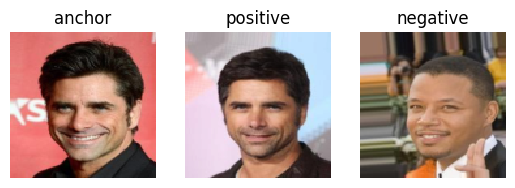

In [ ]:
visualize_triplet(train_loader)

# Model

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v3_small

In [ ]:
class FaceEmbedder(nn.Module):
  def __init__(self, embedding_dim=128):
    super(FaceEmbedder, self).__init__()

    base = mobilenet_v3_small(pretrained=True)

    self.backbone = nn.Sequential(
        base.features,
        nn.AdaptiveAvgPool2d(1),
        nn.Flatten()
    )

    self.embedding_head = nn.Sequential(
        nn.Linear(base.classifier[0].in_features, embedding_dim),
        nn.BatchNorm1d(embedding_dim),
        nn.ReLU(inplace=True),
        nn.Linear(embedding_dim, embedding_dim),
    )

  def forward(self, x):
    x = self.backbone(x)
    x = self.embedding_head(x)
    x = F.normalize(x, p=2, dim=1)
    return x

# Loss

In [ ]:
loss_fn = nn.TripletMarginLoss(margin=0.2)

# Learning

In [ ]:
from tqdm import tqdm
import torch.nn.functional as F

In [ ]:
def train_one_epoch(model, dataloader, optimizer, device):
  model.train()
  total_loss = 0
  total_pos_dist = 0
  total_neg_dist = 0
  total_correct = 0
  count = 0

  for anchor, positive, negative in tqdm(dataloader, desc="Training"):
    anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)

    optimizer.zero_grad()
    emb_anchor = model(anchor)
    emb_positive = model(positive)
    emb_negative = model(negative)

    loss = loss_fn(emb_anchor, emb_positive, emb_negative)
    loss.backward()
    optimizer.step()

    pos_dist = F.pairwise_distance(emb_anchor, emb_positive)
    neg_dist = F.pairwise_distance(emb_anchor, emb_negative)
    correct = (pos_dist < neg_dist).sum().item()

    batch_size = anchor.size(0)
    total_loss += loss.item() * batch_size
    total_pos_dist += pos_dist.sum().item()
    total_neg_dist += neg_dist.sum().item()
    total_correct += correct
    count += batch_size

  avg_loss = total_loss / count
  avg_pos_dist = total_pos_dist / count
  avg_neg_dist = total_neg_dist / count
  accuracy = total_correct / count

  wandb.log({
        "Train Triplet Loss": avg_loss,
        "Train Positive Distance": avg_pos_dist,
        "Train Negative Distance": avg_neg_dist,
        "Train Accuracy": accuracy,
    })

  return avg_loss

In [ ]:
def evaluate(model, dataloader, device):
  model.eval()
  total_loss = 0
  total_pos_dist = 0
  total_neg_dist = 0
  total_correct = 0
  count = 0

  with torch.no_grad():
    for anchor, positive, negative in tqdm(dataloader, desc="Evaluating"):
            anchor = anchor.to(device)
            positive = positive.to(device)
            negative = negative.to(device)

            emb_anchor = model(anchor)
            emb_positive = model(positive)
            emb_negative = model(negative)

            loss = loss_fn(emb_anchor, emb_positive, emb_negative)

            pos_dist = F.pairwise_distance(emb_anchor, emb_positive)
            neg_dist = F.pairwise_distance(emb_anchor, emb_negative)
            correct = (pos_dist < neg_dist).sum().item()

            batch_size = anchor.size(0)
            total_loss += loss.item() * batch_size
            total_pos_dist += pos_dist.sum().item()
            total_neg_dist += neg_dist.sum().item()
            total_correct += correct
            count += batch_size

    avg_loss = total_loss / count
    avg_pos_dist = total_pos_dist / count
    avg_neg_dist = total_neg_dist / count
    accuracy = total_correct / count

    wandb.log({
        "Val Triplet Loss": avg_loss,
        "Val Positive Distance": avg_pos_dist,
        "Val Negative Distance": avg_neg_dist,
        "Val Accuracy": accuracy,
    })

    return avg_loss, avg_pos_dist, avg_neg_dist, accuracy

In [ ]:
def train_model(model, train_loader, val_loader, optimizer, device, num_epochs):
  model.to(device)

  for epoch in range(1, num_epochs + 1):
    print(f"\nEpoch {epoch}/{num_epochs}")

    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    print(f"Train loss: {train_loss:.4f}")

    val_loss, val_pos_dist, val_neg_dist, val_acc = evaluate(model, val_loader, device)
    print(f"Val loss: {val_loss:.4f}, Val_positive_distance: {val_pos_dist:.4f}, Val_negative_distance: {val_neg_dist}, Accuracy: {val_acc:.4f}")

  torch.save(model.state_dict(), "embedder_weights.pth")
  wandb.finish()

# Run learning!

In [ ]:
import wandb

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FaceEmbedder()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth
100%|██████████| 9.83M/9.83M [00:00<00:00, 27.3MB/s]


In [ ]:
device

device(type='cuda')

In [ ]:
wandb.login(key='82d07644b33dce27e12b682550705a879df642e8')

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: elenasapunovaaa (elenasapunovaaa-transbaikal-state-university-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
wandb.init(project='face_embedder', name='26.04_first')

In [ ]:
# import random

# def get_subset(dataset, subset_size):
#     # Выбираем случайное подмножество из датасета
#     indices = random.sample(range(len(dataset)), subset_size)
#     subset = torch.utils.data.Subset(dataset, indices)
#     return subset

In [ ]:
# # Размер подмножества, например, 100 изображений
# subset_size = 25

# # Создаем подмножество данных для быстрого теста
# train_subset = get_subset(train_dataset, subset_size)
# val_subset = get_subset(val_dataset, subset_size)
# test_subset = get_subset(test_dataset, subset_size)

# # Создаем DataLoader'ы для подмножеств
# train_loader_subset = DataLoader(train_subset, batch_size=8, shuffle=True)
# val_loader_subset = DataLoader(val_subset, batch_size=8, shuffle=False)
# test_loader_subset = DataLoader(test_subset, batch_size=8, shuffle=False)

In [ ]:
train_model(model, train_loader, val_loader, optimizer, device, num_epochs=12)


Epoch 1/12


Training: 100%|██████████| 22/22 [00:05<00:00,  4.25it/s]


Train loss: 0.1590


Evaluating: 100%|██████████| 30/30 [00:03<00:00,  9.79it/s]


Val loss: 0.1443, Val_positive_distance: 0.9172, Val_negative_distance: 0.9938330928484599, Accuracy: 0.7125

Epoch 2/12


...

Training: 100%|██████████| 22/22 [00:03<00:00,  5.73it/s]


Train loss: 0.0908


Evaluating: 100%|██████████| 30/30 [00:02<00:00, 12.66it/s]

Val loss: 0.1013, Val_positive_distance: 0.9673, Val_negative_distance: 1.1824518362681071, Accuracy: 0.7917


Train Accuracy,▁▁▃▄▄▆▇▇█▇▇▇
Train Negative Distance,▁▂▃▄▃▆▆▇█▇▇▇
Train Positive Distance,██▇▆▅▅▃▃▁▂▂▁
Train Triplet Loss,██▆▅▅▃▃▂▁▂▂▁
Val Accuracy,▃▂▁▃▄▆▃▆▇█▆▇
Val Negative Distance,▁▄▆▆▇▇▇▇████
Val Positive Distance,▁▆███▆▆▆▅▅▅▄
Val Triplet Loss,█▇▇▆▅▃▅▃▂▁▂▂
Train Accuracy,0.786
Train Negative Distance,1.18115
Train Positive Distance,0.95973


In [ ]:
!cp embedder_weights.pth /content/drive/MyDrive/

cp: cannot create regular file '/content/drive/MyDrive/': No such file or directory
